# Hadamard Gate Measurement

## 1. Problem Statement
Create a 1-qubit quantum circuit, apply a Hadamard gate, measure the qubit, execute it for 1024 shots using Qiskit AerSimulator, and plot the measurement histogram.

---

## 2. Theoretical Overview

### The Hadamard Gate ($H$)
The **Hadamard gate** is a fundamental single-qubit unitary gate that transforms computational basis states into equal superposition states. In matrix form:

$$H = \frac{1}{\sqrt{2}} \begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}$$

When applied to the default ground state $|0\rangle$, the Hadamard gate creates an equal superposition of $|0\rangle$ and $|1\rangle$:

$$H|0\rangle = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle) = |+\rangle$$

Similarly, applying the Hadamard gate to the state $|1\rangle$ yields:

$$H|1\rangle = \frac{1}{\sqrt{2}}(|0\rangle - |1\rangle) = |-\rangle$$

### Equal Superposition and Measurement Probabilities
In the superposition state $|+\rangle$, the quantum state has equal probability amplitudes for computational basis states $|0\rangle$ and $|1\rangle$:

$$\alpha = \frac{1}{\sqrt{2}}, \quad \beta = \frac{1}{\sqrt{2}}$$

According to the **Born rule**, the probability of measuring each basis state upon wavefunction collapse is the squared magnitude of its amplitude:

$$P(0) = |\alpha|^2 = \left|\frac{1}{\sqrt{2}}\right|^2 = \frac{1}{2} = 50\%$$

$$P(1) = |\beta|^2 = \left|\frac{1}{\sqrt{2}}\right|^2 = \frac{1}{2} = 50\%$$

Although quantum measurement is fundamentally probabilistic and collapses the qubit into a definite state ($|0\rangle$ or $|1\rangle$), measuring the circuit repeatedly over many shots (here, 1024 shots) should approximately follow an equal **50/50 probability distribution**.

---

## 3. Tools and Libraries
- **Qiskit**: An open-source quantum computing framework for constructing, optimizing, and executing quantum circuits.
- **Qiskit Aer (`AerSimulator`)**: A high-performance simulator backend for executing quantum circuits with realistic noise models or ideal simulation.
- **Matplotlib**: A standard Python library for data visualization, used here to render the measurement histogram.

### Step 1: Import Required Libraries
Import `QuantumCircuit` from Qiskit for circuit modeling, `AerSimulator` from Qiskit Aer for simulation, and `matplotlib.pyplot` for visualization.

In [2]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

/var/folders/yp/078pyxw11mq6g7sd_2ty18z80000gn/T/ipykernel_4041/2316665587.py:1: DeprecationWarning: Using Qiskit with Python 3.9 is deprecated as of the 2.1.0 release. Support for running Qiskit with Python 3.9 will be removed in the 2.3.0 release, which coincides with when Python 3.9 goes end of life.
  from qiskit import QuantumCircuit


### Step 2: Construct the Quantum Circuit with a Hadamard Gate
Initialize a quantum circuit with 1 qubit and 1 classical bit. Apply a Hadamard gate ($H$) to qubit 0 to create the equal superposition state $|+\rangle$, perform a measurement mapping qubit 0 into classical bit 0, and print the text-based circuit diagram.

In [3]:
shots = 1024

circuit = QuantumCircuit(1,1)

circuit.h(0)

circuit.measure(0,0)

print(circuit.draw())

     ┌───┐┌─┐
  q: ┤ H ├┤M├
     └───┘└╥┘
c: 1/══════╩═
           0 


### Step 3: Simulate Circuit Execution using AerSimulator
Instantiate the `AerSimulator` backend and execute the circuit for $N = 1024$ shots to collect statistical measurement counts.

In [4]:
backend = AerSimulator()

counts = backend.run(circuit,shots=shots).result().get_counts()

print(counts)

{'1': 526, '0': 498}


### Step 4: Visualize Measurement Counts with a Histogram
Plot the observed counts for computational states $|0\rangle$ and $|1\rangle$ using a bar chart with counts annotated on top of each bar.

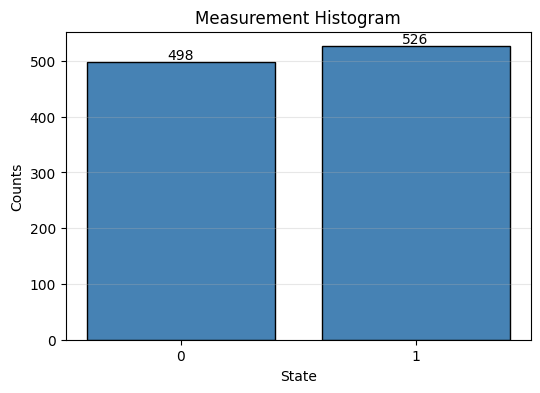

In [5]:
labels = ['0','1']

values = [counts.get(i,0) for i in labels]

plt.figure(figsize=(6,4))

plt.bar(labels,values,color='steelblue',edgecolor='black')

plt.xlabel("State")

plt.ylabel("Counts")

plt.title("Measurement Histogram")

for i,v in enumerate(values):
    plt.text(i,v+5,str(v),ha='center')

plt.grid(axis='y',alpha=0.3)

plt.show()

### Step 5: Compute and Display Experimental Probability Distribution
Calculate the experimental probability for each basis state by dividing measured counts by total shots ($P = \frac{\text{counts}}{\text{shots}}$).

In [6]:
print("Probability Distribution\n")

for state in labels:

    print(f"{state} : {counts.get(state,0)/shots:.4f}")

Probability Distribution

0 : 0.4863
1 : 0.5137


## Conclusion

- **Demonstration of Quantum Superposition**: The experimental measurement counts (498 for state $|0\rangle$ and 526 for state $|1\rangle$ across 1024 shots) demonstrate the probabilistic nature of quantum measurement on a Hadamard-created superposition.
- **Agreement with Theoretical Expectations**: The measured experimental probabilities ($P(0) \approx 0.4863$ and $P(1) \approx 0.5137$) closely align with the theoretical probability of approximately **0.5 (50%)** for each computational basis state.
- **Statistical Variations**: The small deviation from an ideal 512/512 count distribution is expected due to natural statistical shot noise inherent to finite pseudo-random sampling ($N = 1024$). As the number of shots increases, the experimental distribution converges toward the theoretical 50/50 distribution.